# examples

## saildrone

### 20180104/05

In [128]:
import atmPy.radiation.retrievals.broadband_shortwave_radiation as atmbsr
import atmPy.general.measurement_site as atmms
plt.rcParams['figure.dpi'] = 200

In [66]:
dso.close()

In [ ]:
# read and condition the file
## read
fl = ['/Users/htelg/tmp/saildrone-gen4-tpos_2017-sd-1005-20180104T000000-20180104T235959-10hz-v1.1544089890356.nc', '/Users/htelg/tmp/saildrone-gen4-tpos_2017-sd-1005-20180105T000000-20180105T235959-10hz-v1.1544089821364.nc']
out = []
for p2f in fl:
    ds = xr.open_dataset(p2f)
    ds = ds.isel(trajectory = 0)
    ds = ds.set_coords("time").swap_dims({"obs": "time"})
    out.append(ds)

ds = xr.concat(out, 'time')

In [101]:
ds = ds.where(~ds.SW_IRRAD_TOTAL.isnull(), 
         drop = True
        )

In [114]:
ds = ds.sel(time = slice(pd.to_datetime('2018-01-04 15:00:00'), pd.to_datetime('2018-01-05 03:00:00')), drop = True)

In [115]:
ds

<xarray.Dataset> Size: 92MB
Dimensions:                   (time: 215990)
Coordinates:
  * time                      (time) datetime64[ns] 2MB 2018-01-04T15:00:00 ....
    latitude                  (time) float64 2MB 3.874 3.874 ... 3.812 3.812
    longitude                 (time) float64 2MB -134.7 -134.7 ... -134.8 -134.8
    trajectory                float32 4B 1.005e+03
Data variables: (12/50)
    ROLL                      (time) float64 2MB 11.7 11.3 10.7 ... 0.8 2.2 3.8
    PITCH                     (time) float64 2MB 5.3 5.1 2.6 ... 4.5 1.9 -1.3
    HDG                       (time) float64 2MB 174.8 175.7 ... 170.7 170.4
    ROLL_WING                 (time) float64 2MB 10.3 9.6 9.7 ... -0.1 2.9 5.9
    PITCH_WING                (time) float64 2MB 8.9 9.5 7.6 4.1 ... 4.1 2.2 0.2
    HDG_WING                  (time) float64 2MB 153.5 153.4 ... 140.2 141.7
    ...                        ...
    WIND_TARE                 (time) float64 2MB 180.8 180.8 ... 180.8 180.8
    WIND_STATUS               (time) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SW_IRRAD_TOTAL            (time) float64 2MB 1.2 1.2 1.2 0.7 ... 4.9 4.3 5.0
    SW_IRRAD_DIFFUSE          (time) float64 2MB 0.0 0.0 0.0 0.0 ... 2.9 3.0 4.4
    SW_UNMASKED_IRRAD_CENTER  (time) float64 2MB 1.2 1.9 1.9 1.2 ... 3.2 4.5 3.9
    SW_UNMASKED_IRRAD_6DET    (time) float64 2MB 1.9 1.7 1.7 1.7 ... 4.0 4.3 4.1
Attributes: (12/59)
    product_version:                     1
    date_created:                        2018-12-06T09:51:30.357885Z
    time_coverage_start:                 2018-01-04T00:00:00.000000Z
    time_coverage_end:                   2018-01-04T23:59:59.999000Z
    data_mode:                           delay-mode
    drone_id:                            1005
    ...                                  ...
    institution:                         NOAA Pacific Marine Environmental La...
    interval:                            1
    project:                             TPOS_2017
    summary:                             This file contains high resolution d...
    title:                               NOAA PMEL TPOS 2017 High Resolution ...
    wmo_id:                              5801952

In [131]:
%matplotlib inline

In [132]:
# %matplotlib widget

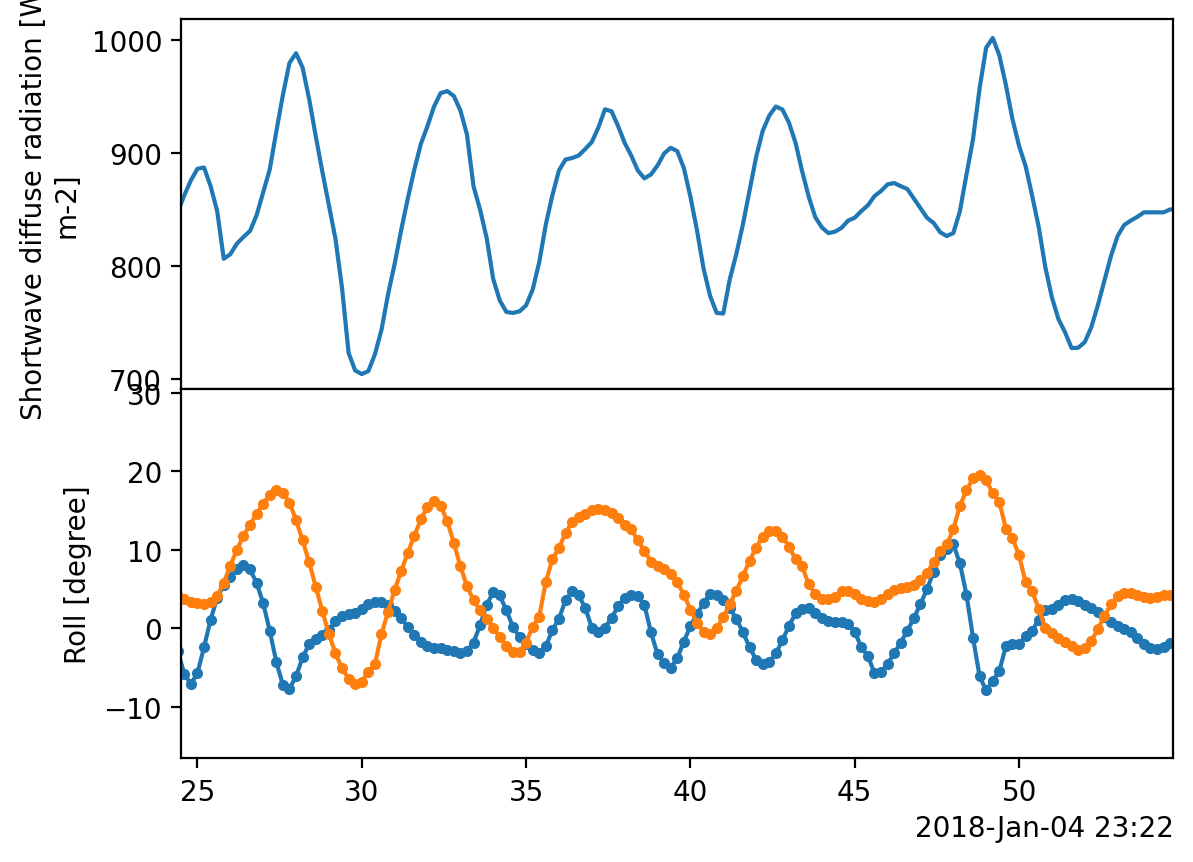

In [136]:
f,aa = plt.subplots(2,sharex=True, gridspec_kw={'hspace': 0})
a = aa[0]
ds.SW_IRRAD_TOTAL.plot(ax = a)
ds.SW_IRRAD_DIFFUSE.plot(ax = a)
a = aa[1]
ds.PITCH.plot(ax = a, marker = '.')
ds.ROLL.plot(ax = a, marker = '.')

a = aa[0]
a.set_ylim(np.float64(691.4781854990188), np.float64(1018.8186483905149))
a.set_xlim(np.float64(17535.973894827766), np.float64(17535.974244202218))

for a in aa:
    a.set_title('')
    a.set_xlabel('')

In [157]:
ds = ds.rename_dims({'time': 'datetime'})

In [167]:
ds['altitude'] = xr.zeros_like(ds.datetime)

In [168]:
ds.rename_vars({SW_IRRAD_TOTAL}

<xarray.Dataset> Size: 93MB
Dimensions:                   (datetime: 215990)
Coordinates:
  * time                      (datetime) datetime64[ns] 2MB 2018-01-04T15:00:...
    latitude                  (datetime) float64 2MB 3.874 3.874 ... 3.812 3.812
    longitude                 (datetime) float64 2MB -134.7 -134.7 ... -134.8
    trajectory                float32 4B 1.005e+03
Dimensions without coordinates: datetime
Data variables: (12/51)
    ROLL                      (datetime) float64 2MB 11.7 11.3 10.7 ... 2.2 3.8
    PITCH                     (datetime) float64 2MB 5.3 5.1 2.6 ... 1.9 -1.3
    HDG                       (datetime) float64 2MB 174.8 175.7 ... 170.7 170.4
    ROLL_WING                 (datetime) float64 2MB 10.3 9.6 9.7 ... 2.9 5.9
    PITCH_WING                (datetime) float64 2MB 8.9 9.5 7.6 ... 4.1 2.2 0.2
    HDG_WING                  (datetime) float64 2MB 153.5 153.4 ... 140.2 141.7
    ...                        ...
    WIND_STATUS               (datetime) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SW_IRRAD_TOTAL            (datetime) float64 2MB 1.2 1.2 1.2 ... 4.9 4.3 5.0
    SW_IRRAD_DIFFUSE          (datetime) float64 2MB 0.0 0.0 0.0 ... 2.9 3.0 4.4
    SW_UNMASKED_IRRAD_CENTER  (datetime) float64 2MB 1.2 1.9 1.9 ... 3.2 4.5 3.9
    SW_UNMASKED_IRRAD_6DET    (datetime) float64 2MB 1.9 1.7 1.7 ... 4.0 4.3 4.1
    altitude                  (datetime) int64 2MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
Attributes: (12/59)
    product_version:                     1
    date_created:                        2018-12-06T09:51:30.357885Z
    time_coverage_start:                 2018-01-04T00:00:00.000000Z
    time_coverage_end:                   2018-01-04T23:59:59.999000Z
    data_mode:                           delay-mode
    drone_id:                            1005
    ...                                  ...
    institution:                         NOAA Pacific Marine Environmental La...
    interval:                            1
    project:                             TPOS_2017
    summary:                             This file contains high resolution d...
    title:                               NOAA PMEL TPOS 2017 High Resolution ...
    wmo_id:                              5801952

In [ ]:
ds.HDG

In [ ]:
ds = ds.rename_vars({'SW_IRRAD_TOTAL': 'global_horizontal',
               'SW_IRRAD_DIFFUSE': 'diffuse_horizontal',
               'PITCH': 'platform_pitch',
               'ROLL': 'platform_roll',
               'HDG': 'platform_heading',})

ds.global_horizontal.attrs['units'] = 'W/m^2'
ds.diffuse_horizontal.attrs['units'] = 'W/m^2'

ds['platform_pitch'] = np.deg2rad(ds.platform_pitch)
ds.platform_pitch.attrs['units'] = 'radian'
ds['platform_roll'] = np.deg2rad(ds.platform_roll)
ds.platform_roll.attrs['units'] = 'radian'
ds['platform_heading'] = np.deg2rad(ds.platform_heading)
ds.platform_heading.attrs['units'] = 'radian'

In [223]:
reload(atmbsr)
reload(atmbsr.tiltcorrection)

<module 'atmPy.radiation.retrievals.tiltcorrection' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/tiltcorrection.py'>

In [227]:
rin = atmbsr.CombinedGlobalDiffuseDirect(ds, verbose = True)
self = rin

In [228]:
out = rin.apply_tilt_correction()
out

AssertionError: pitch variable must have a "positive" attribute indicating the positive direction of pitch. Positive pitch should be nose-up.

No site provided, trying to infer site information from dataset.
Found latitude and longitude in dataset variables. Latitude and longitude are time dependent. Assuming moving platform.


/Users/htelg/prog/atm-py/atmPy/general/measurement_site.py:1166: UserWarning: Non-finite path coordinates were ignored
  warnings.warn('Non-finite path coordinates were ignored')


(<Figure size 1280x960 with 1 Axes>, <GeoAxes: >)

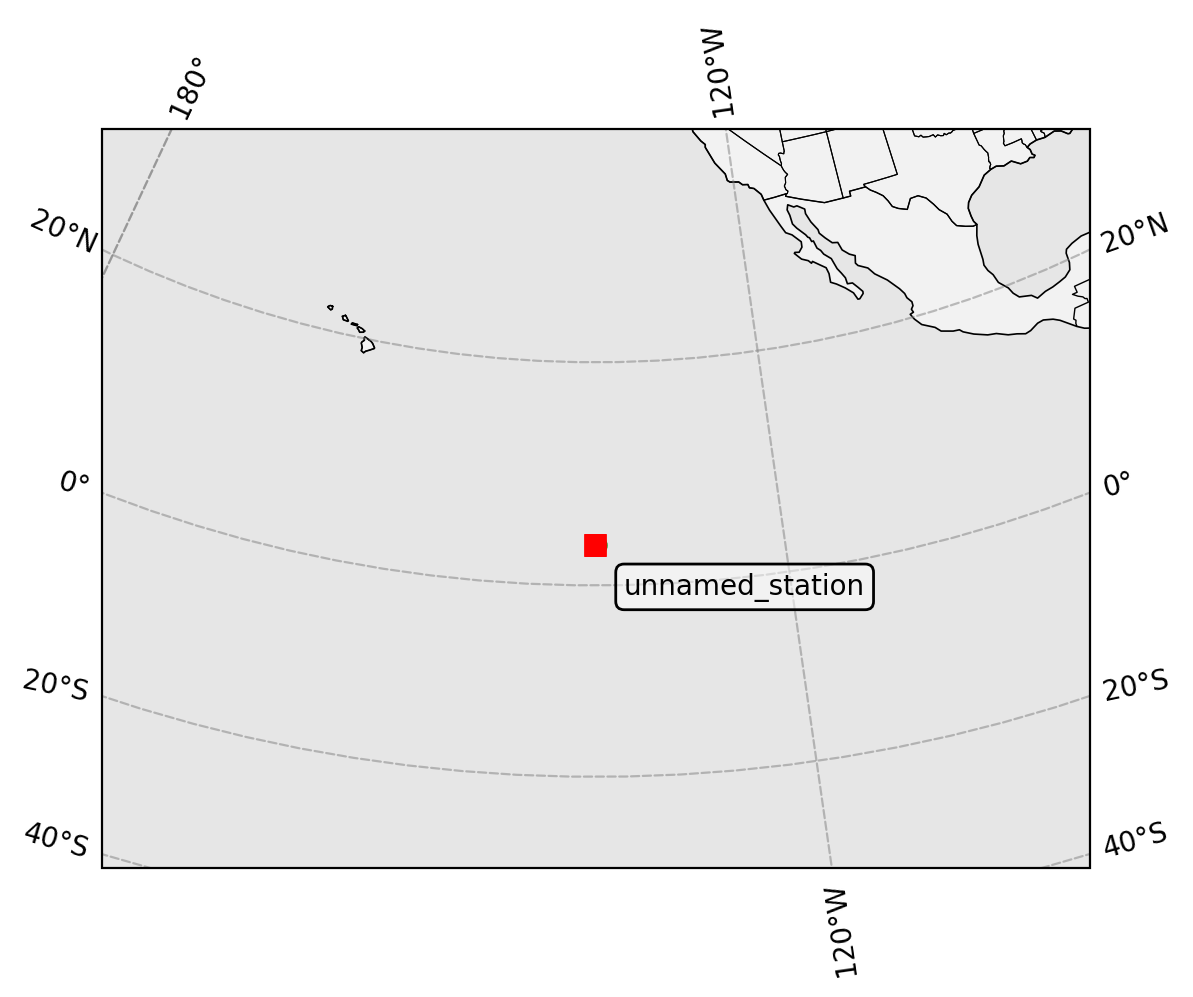

In [185]:
rin.site.plot_path(extent_pad=2**5, zoom_level=1)
# rin.sun_position

In [18]:
out.dataset

In [11]:
f,a = plt.subplots()
ds.global_horizontal.plot()
out.dataset.global_horizontal.plot(ax = a)
out.dataset.direct_normal.plot(ax = a)
out.dataset.diffuse_horizontal.plot(ax = a)
a.set_ylim(0, 1200)
f.autofmt_xdate()

### minute data good for finding clear days

In [83]:
import atmPy.radiation.retrievals.broadband_shortwave_radiation as atmbsr
import atmPy.general.measurement_site as atmms

In [66]:
dso.close()

In [74]:
# read and condition the file
## read
# dso = xr.open_dataset('/Users/htelg/tmp/saildrone-gen_4-tpos_2017_spurs2-sd1005-20171022T000000-20171022T235959-100_milliseconds-v1.1538186026756.nc')
# dso = xr.open_dataset('/Users/htelg/tmp/saildrone-gen4-tpos_2017-sd-1005-20171022T000000-20171022T235959-1hz-v1.1544037103502.nc') #does not have any shortwave radiation, just long
dso = xr.open_dataset('/Users/htelg/tmp/TPOS-2017_SD1005_1min.nc') # this has some good data, but low temporal res: 1 min, could be too slow
# dso = xr.open_dataset('/Users/htelg/tmp/SD1005adcp2017_v2.nc') # this is something else.

In [46]:
ds = dso.set_coords("time").swap_dims({"row": "time"})

In [47]:
ds

<xarray.Dataset> Size: 195MB
Dimensions:                          (time: 368640)
Coordinates:
  * time                             (time) datetime64[ns] 3MB 2017-09-02 ......
Data variables: (12/65)
    trajectory                       (time) object 3MB ...
    latitude                         (time) float64 3MB ...
    longitude                        (time) float64 3MB ...
    TEMP_O2_STDDEV                   (time) float64 3MB ...
    SW_UNMASKED_IRRAD_CENTER_MEAN    (time) float64 3MB ...
    CHLOR_MEAN                       (time) float64 3MB ...
    ...                               ...
    COG                              (time) float64 3MB ...
    WING_ANGLE                       (time) float64 3MB ...
    PITCH                            (time) float64 3MB ...
    wind_speed                       (time) float64 3MB ...
    wind_dir                         (time) float64 3MB ...
    distance_1005_1006               (time) float64 3MB ...
Attributes: (12/67)
    acknowledgement:                     If you use these data in publication...
    area:                                California to 0N 125W and back
    cdm_data_type:                       Trajectory
    cdm_trajectory_variables:            trajectory
    citation:                            Please cite Zhang et al. (2019) when...
    contributor_email:                   Nathan.anderson@noaa.gov; dongxiao.z...
    ...                                  ...
    publisher_name:                      NOAA PMEL
    publisher_url:                       pmel.noaa.gov
    time_in:                             seconds
    source:                              NOAA Saildrone Missions
    doi_comment:                         The DOI for this data was minted aga...
    doi:                                 http://doi.org/10.25921/hxp3-g978

In [56]:
%matplotlib widget

In [60]:
f,aa = plt.subplots(2,sharex=True, gridspec_kw={'hspace': 0})
a = aa[0]
ds.SW_IRRAD_TOTAL_MEAN.plot(ax = a)
ds.SW_IRRAD_DIFFUSE_MEAN.plot(ax = a)
a = aa[1]
ds.PITCH.plot(ax = a)
ds.ROLL.plot(ax = a)

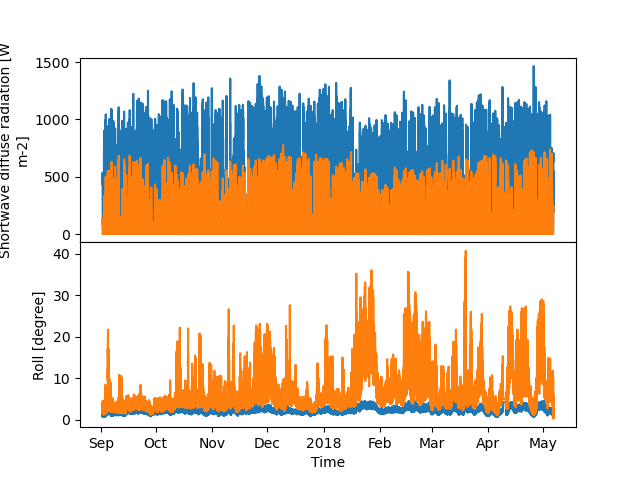

In [61]:
f.show()

In [71]:
a.set_xlim(np.float64(17648.47749598058), np.float64(17649.394901693464)) # high roll, up to 20 deg


(np.float64(17648.47749598058), np.float64(17649.394901693464))

In [72]:
a.set_xlim(np.float64(17535.582321877344), np.float64(17536.33633902222)) # high roll up to 10 degrees pitch 2 deg

(np.float64(17535.582321877344), np.float64(17536.33633902222))

In [70]:
a.set_xlim(np.float64(17514.44861329742), np.float64(17515.271308748957)) #roll is up to 8 degrees

(np.float64(17514.44861329742), np.float64(17515.271308748957))

In [54]:
f,a = plt.subplots()
ds.PITCH.plot(ax = a)
ds.ROLL.plot(ax = a)

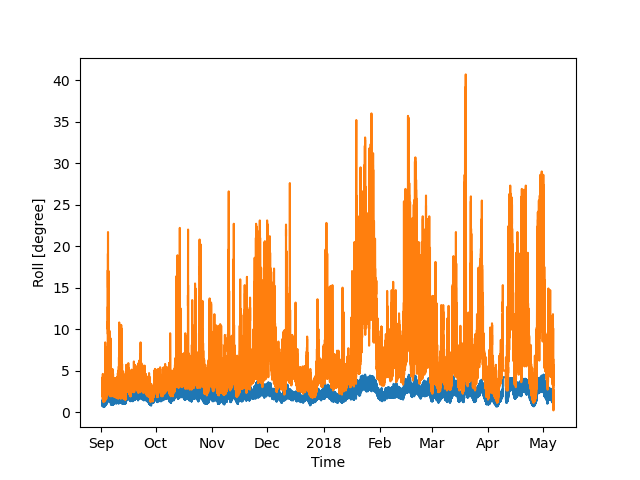

In [55]:
f.show()

In [76]:
ds = dso.isel(trajectory = 0)

In [77]:
ds = ds.where(~ds.SW_IRRAD_TOTAL.isnull(), 
         drop = True
        )

In [78]:
ds = ds.swap_dims({"obs": "time"})

In [79]:
ds

<xarray.Dataset> Size: 187MB
Dimensions:                   (time: 431991)
Coordinates:
  * time                      (time) datetime64[ns] 3MB 2017-10-22T00:00:00.2...
    latitude                  (time) float64 3MB 10.07 10.07 ... 10.04 10.04
    longitude                 (time) float64 3MB -125.1 -125.1 ... -125.0 -125.0
    trajectory                float32 4B 1.005e+03
Data variables: (12/51)
    ROLL                      (time) float64 3MB 3.3 4.2 5.6 ... -1.5 -1.9 -2.0
    PITCH                     (time) float64 3MB 0.2 1.0 1.9 ... -4.1 -4.7 -4.4
    HDG                       (time) float64 3MB 217.0 216.6 ... 200.3 198.5
    ROLL_WING                 (time) float64 3MB -0.9 -1.4 -2.5 ... 5.8 6.0 5.5
    PITCH_WING                (time) float64 3MB 3.9 4.2 4.8 ... -0.6 -1.0 -1.0
    HDG_WING                  (time) float64 3MB 104.3 104.0 ... 104.1 102.9
    ...                        ...
    WIND_STATUS               (time) float64 3MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    WIND_STATUS_49            (time) float64 3MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SW_IRRAD_TOTAL            (time) float64 3MB 170.0 169.8 ... 327.4 324.7
    SW_IRRAD_DIFFUSE          (time) float64 3MB 159.0 157.5 155.8 ... 87.1 87.1
    SW_UNMASKED_IRRAD_CENTER  (time) float64 3MB 159.7 159.1 ... 311.1 311.1
    SW_UNMASKED_IRRAD_6DET    (time) float64 3MB 159.8 159.8 ... 307.9 307.1
Attributes: (12/34)
    title:                     Saildrone TPOS 2017 SPURS-2
    summary:                    Two Saildrones, each a with full atmospheric ...
    ncei_template_version:     NCEI_NetCDF_Trajectory_Template_v2.0
    Conventions:               CF-1.6, ACDD-1.3
    netcdf_version:            4.4.1.1
    featureType:               trajectory
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        -125.0756916
    geospatial_lon_max:        -124.9812358
    geospatial_lon_units:      degrees_east
    project:                   tpos_2017_spurs2
    product_version:           1

In [80]:
ds

<xarray.Dataset> Size: 187MB
Dimensions:                   (time: 431991)
Coordinates:
  * time                      (time) datetime64[ns] 3MB 2017-10-22T00:00:00.2...
    latitude                  (time) float64 3MB 10.07 10.07 ... 10.04 10.04
    longitude                 (time) float64 3MB -125.1 -125.1 ... -125.0 -125.0
    trajectory                float32 4B 1.005e+03
Data variables: (12/51)
    ROLL                      (time) float64 3MB 3.3 4.2 5.6 ... -1.5 -1.9 -2.0
    PITCH                     (time) float64 3MB 0.2 1.0 1.9 ... -4.1 -4.7 -4.4
    HDG                       (time) float64 3MB 217.0 216.6 ... 200.3 198.5
    ROLL_WING                 (time) float64 3MB -0.9 -1.4 -2.5 ... 5.8 6.0 5.5
    PITCH_WING                (time) float64 3MB 3.9 4.2 4.8 ... -0.6 -1.0 -1.0
    HDG_WING                  (time) float64 3MB 104.3 104.0 ... 104.1 102.9
    ...                        ...
    WIND_STATUS               (time) float64 3MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    WIND_STATUS_49            (time) float64 3MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SW_IRRAD_TOTAL            (time) float64 3MB 170.0 169.8 ... 327.4 324.7
    SW_IRRAD_DIFFUSE          (time) float64 3MB 159.0 157.5 155.8 ... 87.1 87.1
    SW_UNMASKED_IRRAD_CENTER  (time) float64 3MB 159.7 159.1 ... 311.1 311.1
    SW_UNMASKED_IRRAD_6DET    (time) float64 3MB 159.8 159.8 ... 307.9 307.1
Attributes: (12/34)
    title:                     Saildrone TPOS 2017 SPURS-2
    summary:                    Two Saildrones, each a with full atmospheric ...
    ncei_template_version:     NCEI_NetCDF_Trajectory_Template_v2.0
    Conventions:               CF-1.6, ACDD-1.3
    netcdf_version:            4.4.1.1
    featureType:               trajectory
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        -125.0756916
    geospatial_lon_max:        -124.9812358
    geospatial_lon_units:      degrees_east
    project:                   tpos_2017_spurs2
    product_version:           1

In [18]:
%matplotlib widget

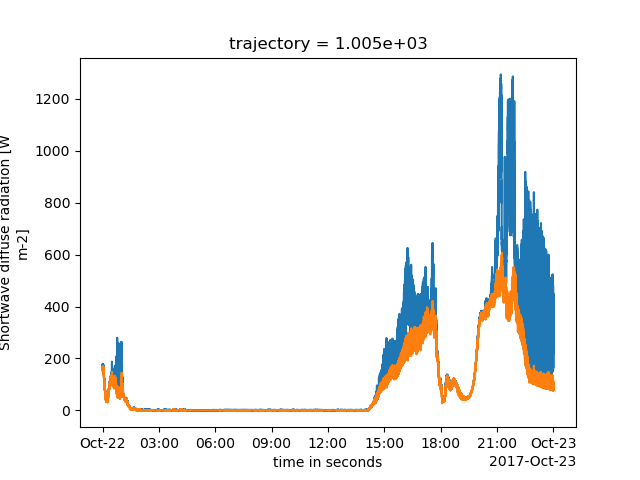

In [81]:
f,a = plt.subplots()
ds.SW_IRRAD_TOTAL.plot(marker = '', ax = a)
ds.SW_IRRAD_DIFFUSE.plot(ax = a)

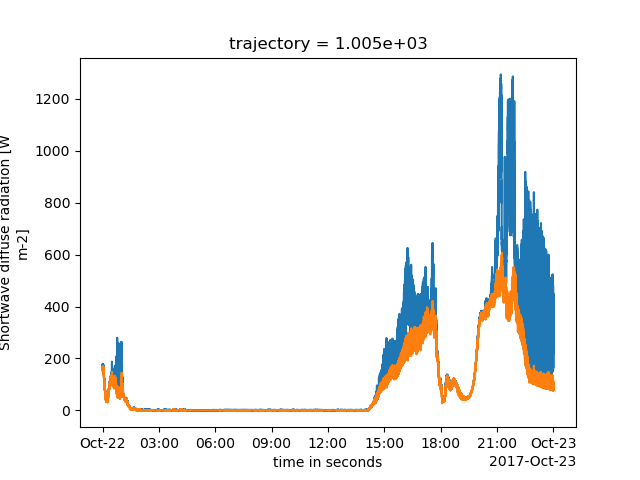

In [82]:
f.show()

## "redo" the Long2010 figure

Note, in this example below I am correcting already corrected data, so it is not expected to look good, but you can tell if the correctio is similar to the correcection that is already applie by checkking Long 2010 Figure xy (forgot wich figure it was)

In [1]:
import atmPy.radiation.retrievals.broadband_shortwave_radiation as atmbsr
import atmPy.general.measurement_site as atmms

In [2]:
plt.rcParams['figure.dpi'] = 200

In [3]:
def convert_degree2radian(da):
    assert(da.units == 'degree'), 'nosososs'
    out = np.deg2rad(da)
    out.attrs['units'] = 'radian'
    return out

In [4]:
ds.close()

NameError: name 'ds' is not defined

In [5]:
ds = xr.open_dataset('racoro.20090527.175738.cdf')

ds

ds = ds.rename({'aircraft_roll': 'platform_roll'})
ds['platform_roll'] = convert_degree2radian(ds.platform_roll)
ds.platform_roll.attrs['positive'] = 'right-side-down'

ds = ds.rename({'aircraft_pitch': 'platform_pitch'})
ds['platform_pitch'] = convert_degree2radian(ds.platform_pitch) 
ds.platform_pitch.attrs['positive'] = 'nose-up'

ds = ds.rename({'aircraft_head': 'platform_heading'})
ds['platform_heading'] = convert_degree2radian(ds.platform_heading)
ds = ds.rename({'zen_swflx_cm22': 'global_horizontal'})

ds = ds.rename({'dir_swflx_spn1': 'direct_horizontal'})

ds['direct_horizontal'] = ds.direct_horizontal.where(ds.direct_horizontal >-1000)
ds['global_horizontal'] = ds.global_horizontal.where(ds.global_horizontal >-1000)

ds = ds.rename({'lat': 'latitude', 'lon':'longitude'})
ds['longitude'] = - ds.longitude

ds = ds.rename({'gps_alt': 'altitude'})

ds['diffuse_horizontal'] = ds.global_horizontal - ds.direct_horizontal

ds = ds.rename({'time': 'datetime'})
dt = pd.to_datetime(ds.base_time.values) + pd.to_timedelta(ds.time_offset, unit='s')
ds = ds.assign_coords({'datetime':dt})

In [6]:
reload(atmbsr)
reload(atmbsr.tiltcorrection)
reload(atmbsr.atmgms)

<module 'atmPy.general.measurement_site' from '/Users/htelg/prog/atm-py/atmPy/general/measurement_site.py'>

In [7]:
rin = atmbsr.CombinedGlobalDiffuseDirect(ds)
self = rin

# rin.site.plot_path(extent_pad=4, zoom_level=4)
# rin.sun_position

In [8]:
out = rin.apply_tilt_correction()
out

In [18]:
out.dataset

<xarray.Dataset> Size: 377kB
Dimensions:             (datetime: 13459)
Coordinates:
  * datetime            (datetime) datetime64[ns] 108kB 2009-05-27T17:57:38.9...
Data variables:
    global_horizontal   (datetime) float64 108kB 310.5 311.0 ... 347.8 350.5
    diffuse_horizontal  (datetime) float32 54kB 305.3 306.2 ... 347.5 348.9
    direct_normal       (datetime) float64 108kB 5.477 4.959 ... 0.491 2.239

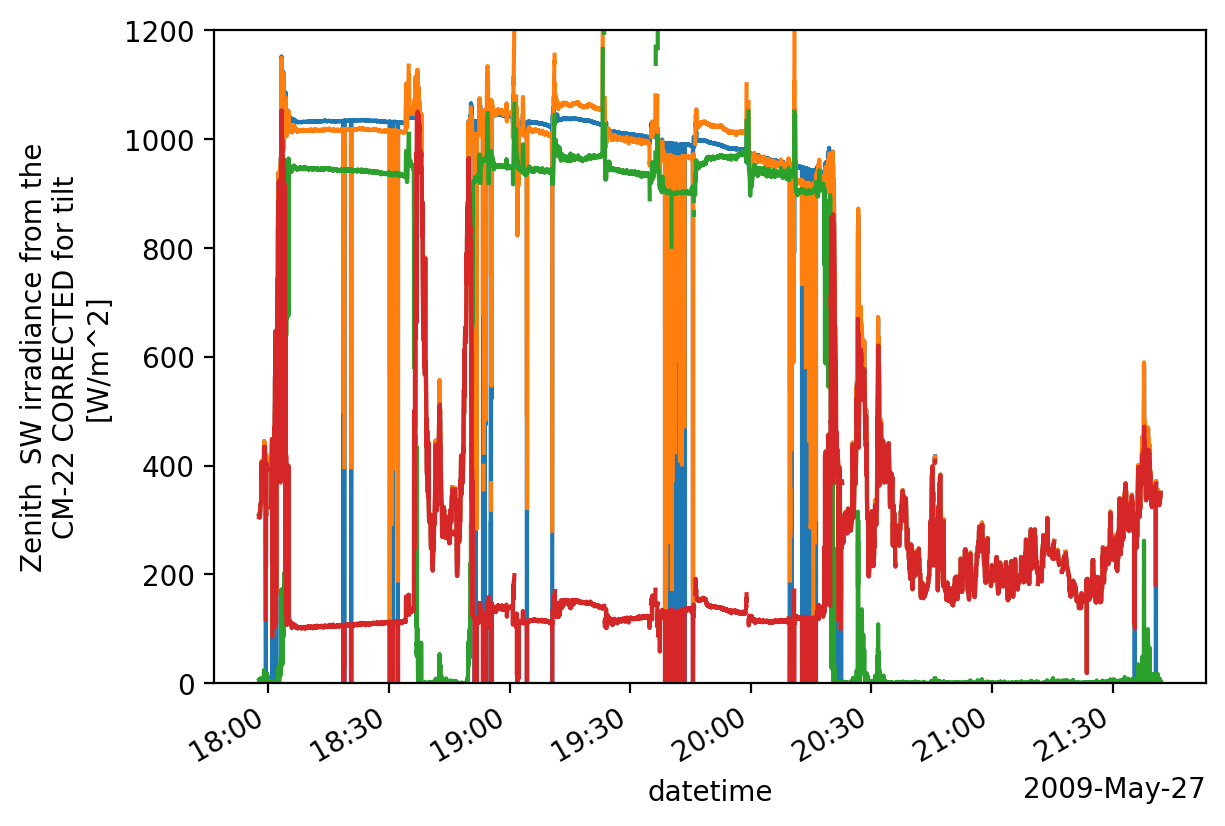

In [11]:
f,a = plt.subplots()
ds.global_horizontal.plot()
out.dataset.global_horizontal.plot(ax = a)
out.dataset.direct_normal.plot(ax = a)
out.dataset.diffuse_horizontal.plot(ax = a)
a.set_ylim(0, 1200)
f.autofmt_xdate()

# sun incidence angel playground

In [1]:
import atmPy.radiation.retrievals.tiltcorrection as atmtilt

/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/tiltcorrection.py:83: SyntaxWarning: invalid escape sequence '\m'
  $N$ the direct normal component, $\mathrm{Diff}$ the diffuse component, $\mu_t$ the


In [4]:
# plain flys in the sun and tilts nose up -> zenith angle gets larger
out = atmtilt.solar_incidence_angle(zenith = np.deg2rad(20), 
                              azimuth = np.deg2rad(90), 
                              pitch = np.deg2rad(1),
                              roll = np.deg2rad(0),
                              heading = np.deg2rad(90))
np.rad2deg(out)

np.float64(20.999999999999986)

In [9]:
# opposite heading
out = atmtilt.solar_incidence_angle(zenith = np.deg2rad(20), 
                              azimuth = np.deg2rad(90), 
                              pitch = np.deg2rad(1),
                              roll = np.deg2rad(0),
                              heading = np.deg2rad(90+180))
np.rad2deg(out)

np.float64(18.999999999999975)

In [8]:
# plain flys in the paralel to the sun and rols right side down (positive roll) -> zenith angle gets smaller
out = atmtilt.solar_incidence_angle(zenith = np.deg2rad(20), 
                              azimuth = np.deg2rad(180), 
                              pitch = np.deg2rad(0),
                              roll = np.deg2rad(1),
                              heading = np.deg2rad(90))
np.rad2deg(out)

np.float64(18.999999999999975)

In [10]:
# oposite heading
out = atmtilt.solar_incidence_angle(zenith = np.deg2rad(20), 
                              azimuth = np.deg2rad(180), 
                              pitch = np.deg2rad(0),
                              roll = np.deg2rad(1),
                              heading = np.deg2rad(90+180))
np.rad2deg(out)

np.float64(20.999999999999986)

np.float64(20.023961889117096)

# Solving the linear equations getting tilt corrected direct and global

In [13]:
import sympy as sp

Let $G_t$ denote the measured total irradiance, $G_0$ the corrected total irradiance, 
$N$ the direct normal component, $\mathrm{Diff}$ the diffuse component, $\mu_t$ the 
cosine of the tilted solar zenith angle, $\mu_0$ the cosine of the horizontal solar 
zenith angle, and $\mathrm{dgr}$ the diffuse-global ratio of tilted observations.

Solving the system

$$
\begin{aligned}
G_t &= N\mu_t + \mathrm{Diff} \\
G_0 &= N\mu_0 + \mathrm{Diff} \\
\mathrm{dgr} &= \frac{\mathrm{Diff}}{G_t}
\end{aligned}
$$

for the unknowns $G_0$, $N$, and $\mathrm{Diff}$, in terms of the remaining variables $G_t$, $\mu_t$, $\mu_0$, and $\mathrm{dgr}$, yields

$$
\begin{aligned}
G_0 &= \frac{-G_t~\mathrm{dgr}~\mu_0 + G_t~\mathrm{dgr}~\mu_t + G_t~\mu_0}{\mu_t}\\
N &= \frac{-G_t~\mathrm{dgr} + G_t}{\mu_t} \\
\mathrm{Diff} &= G_t~\mathrm{dgr}
\end{aligned}
$$

In [14]:
# based on the ratio of diffuse and global. This is preferable as it uses two measurments that are actually observed
Gt, N, mut, mu0, Diff, G0, ddt = sp.symbols("Gt N mut mu0 Diff G0 ddt") 

#equations
eqs = [sp.Eq(Gt, N * mut + Diff), 
       sp.Eq(G0, N * mu0 + Diff), 
       sp.Eq(ddt, Diff/Gt), ] 
sol = sp.solve(eqs, [G0, N,Diff], dict=True)
sol

[{Diff: Gt*ddt,
  G0: (-Gt*ddt*mu0 + Gt*ddt*mut + Gt*mu0)/mut,
  N: (-Gt*ddt + Gt)/mut}]